# 33.3 · Stable interaction and virtual pointers

CPU · Python 3.11–3.13 · seeded teaching experiment

[Open in Google Colab](https://colab.research.google.com/) — use the [ZIP setup workflow](../../docs/colab.md). No model or dataset downloads occur in this notebook.

## Learning Objectives

- Explain stable interaction and virtual pointers using the chapter's assumptions.
- Translate the worked equation into Python and inspect an implementation.
- Run, visualize and critique a reproducible experiment.

## Prerequisites

[18 · Object Tracking](../../18-object-tracking/README.md), [32 · Pose Estimation](../../32-pose-estimation/README.md)

Install the repository before opening this notebook: `python -m pip install -e ".[notebooks,deep,api]"`. The deep/API extras are needed only by chapters that use them.

## 1. Introduction

Hand tracking combines landmark detection, temporal consistency and a gesture interpretation layer. Landmarks provide coordinates; a gesture controller still needs normalization, state and debouncing. Image-space motion should not automatically become an operating-system action.

## 2. Intuition

A virtual pointer maps a selected landmark into a bounded interaction region, smooths motion and confirms clicks with a state machine. The lab visualizes pointer coordinates without moving the system mouse. The optional detector adapter returns landmarks; a real controller must add explicit user enable/disable controls and a reliable escape action.

In [1]:
import inspect
import json
import platform
from importlib.metadata import version

import cv2
import numpy as np
from IPython.display import Code, display

from cvzero.course.runner import lab_function, run

CHAPTER = 33
LESSON = 2
SEED = 42
AMOUNT = 1.0
print(
    {
        "python": platform.python_version(),
        "numpy": version("numpy"),
        "opencv": cv2.__version__,
        "device": "cpu",
        "seed": SEED,
    }
)

{'python': '3.12.14', 'numpy': '2.3.5', 'opencv': '4.14.0', 'device': 'cpu', 'seed': 42}


## 3. Mathematical Foundation

$$
r=\lVert p_{thumb}-p_{index}\rVert/\lVert p_{wrist}-p_{middle}\rVert
$$

r is a scale-normalized pinch ratio. If fingertip distance is 10 pixels and reference hand length 80 pixels, r=0.125. A zero reference length makes the feature invalid.

Read the symbols aloud, predict the numerical result, and only then execute the worked example.

## 4. Visual Explanation

The chapter preview shows an actual baseline run. Read every panel title before interpreting color or brightness; some panels show a mask, an error, or a matrix rather than a photograph.

![Measured chapter baseline](../assets/lab-preview.png)

## 5. Basic Implementation

This small calculation isolates the equation from the larger pipeline. Change one number and predict its effect before rerunning.

In [2]:
tip_distance, reference_length = 10.0, 80.0
pinch_ratio = tip_distance / reference_length
assert np.isclose(pinch_ratio, 0.125)
print(pinch_ratio)

0.125


## 6. OpenCV Implementation

The relevant library is selected by the problem: OpenCV for image operations and geometry, scikit-learn for classical learning, PyTorch for differentiable models, and FastAPI for service contracts. OpenCV handles image arrays where it is useful; it does not supply every advanced model.

Synthetic landmarks make indexing, distance normalization and pointer mapping inspectable. No live hand accuracy or OS-control behavior is claimed by the default lab.

The lab function below calls the actual implementation. Inspect its source to see preprocessing, fixed hyperparameters and reported metrics.

In [3]:
display(Code(inspect.getsource(lab_function(CHAPTER)), language="python"))
result = run(CHAPTER, lesson=LESSON, seed=SEED, amount=AMOUNT)
print(json.dumps(result.metrics, indent=2))
print(result.notes)

def hands(lesson, seed, amount):
    palm = np.array(
        [
            [48, 75],
            [30, 55],
            [24, 43],
            [20, 32],
            [17, 22],
            [37, 50],
            [36, 33],
            [35, 21],
            [35, 10],
            [48, 49],
            [48, 29],
            [48, 17],
            [48, 5],
            [59, 51],
            [61, 34],
            [62, 22],
            [63, 12],
            [68, 57],
            [73, 43],
            [76, 33],
            [79, 23],
        ],
        float,
    )
    if lesson == 1:
        palm[8] = [42, 46]
    if lesson == 2:
        palm[4] = palm[8] + [3 * amount, 0]
    canvas = np.zeros((88, 96, 3), np.uint8)
    for start in [1, 5, 9, 13, 17]:
        chain = [0] + list(range(start, start + 4))
        for a, b in zip(chain[:-1], chain[1:]):
            cv2.line(
                canvas, tuple(palm[a].astype(int)), tuple(palm[b].astype(int)), (40, 180, 210), 1
            )
    for point in palm:
        cv2.circle(canvas, tuple(point.astype(int)), 2, (255, 220, 80), -1)
    distance = np.linalg.norm(palm[4] - palm[8]) / np.linalg.norm(palm[0] - palm[9])
    return Result(
        "33 · Hand landmark geometry and virtual interaction",
        {"Synthetic 21-landmark hand": canvas},
        metrics={
            "normalized_pinch_distance": float(distance),
            "pinch_detected": bool(distance < 0.3),
            "pointer_normalized_xy": (palm[8] / [96, 88]).tolist(),
        },
        notes="A safe virtual-pointer calculation; no operating-system mouse clicks are performed. Real landmarks require the optional hand detector.",
    )

{
  "normalized_pinch_distance": 0.11538461538461539,
  "pinch_detected": true,
  "pointer_normalized_xy": [
    0.3645833333333333,
    0.11363636363636363
  ]
}
A safe virtual-pointer calculation; no operating-system mouse clicks are performed. Real landmarks require the optional hand detector.


## 7. From-Scratch Implementation

Read the following reusable reference implementation line by line. Identify input shapes, the main update or reduction, and the boundary/invalid-input policy. Its source lives in `src/cvzero/course/tracking.py`; notebooks reuse it so fixes apply everywhere. Optimized libraries are compared where matching behavior is meaningful.

In [4]:
from cvzero.course.tracking import joint_angle

display(Code(inspect.getsource(joint_angle), language="python"))

def joint_angle(a, b, c):
    """Angle ABC in degrees; reject a zero-length limb."""
    u, v = np.asarray(a) - b, np.asarray(c) - b
    length = np.linalg.norm(u) * np.linalg.norm(v)
    if length < 1e-10:
        raise ValueError("Cannot measure an angle with a zero-length limb.")
    return float(np.degrees(np.arccos(np.clip(u @ v / length, -1, 1))))

## 8. Experiment

Scale all landmark coordinates by two and verify that a normalized pinch ratio stays constant. Add noise and inspect click stability.

The run configuration is defined above. `lesson` selects the chapter experiment, `seed` fixes generated data or initialization, and `amount` controls the active experiment's perturbation when supported. Consult the displayed function before changing it: a fixed mathematical example may deliberately ignore a random seed or perturbation. Keep all other settings fixed when testing one hypothesis.

In [5]:
# A second independent seed checks sensitivity; fixed examples may remain identical.
repeat = run(CHAPTER, lesson=LESSON, seed=SEED + 1, amount=AMOUNT)
print(json.dumps({"baseline": result.metrics, "second_seed": repeat.metrics}, indent=2))

{
  "baseline": {
    "normalized_pinch_distance": 0.11538461538461539,
    "pinch_detected": true,
    "pointer_normalized_xy": [
      0.3645833333333333,
      0.11363636363636363
    ]
  },
  "second_seed": {
    "normalized_pinch_distance": 0.11538461538461539,
    "pinch_detected": true,
    "pointer_normalized_xy": [
      0.3645833333333333,
      0.11363636363636363
    ]
  }
}


## 9. Visualization

These figures are generated by the current run. The second plot uses the second seed. Compare the numerical report with the visible result; a single scalar rarely explains every failure.

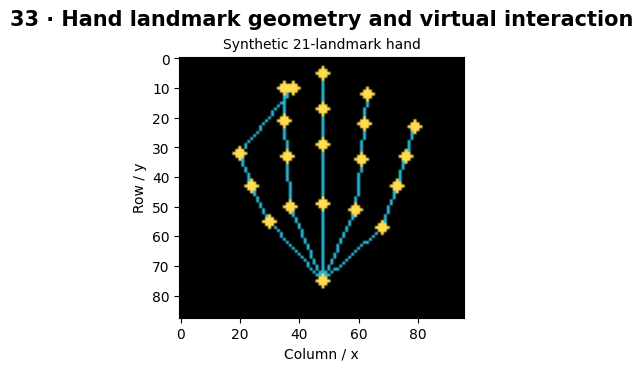

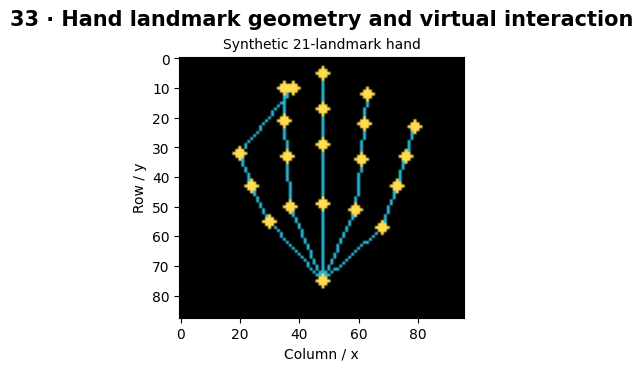

In [6]:
display(result.plot())
display(repeat.plot())

## 10. Real-World Application

The chapter mini project is **Virtual Pointer Simulator**. Convert landmarks into reversible desktop interactions. Start with the generated data so expected geometry or labels are known, then use a separately documented real dataset. Do not transfer synthetic metrics to a real deployment claim.

## 11. Common Mistakes

Raw pixel thresholds change with distance from the camera. Mirroring the display without adjusting coordinates reverses interaction.

Check shape, dtype, units, split and coordinate conventions before tuning an algorithm.

## 12. Exercises

- **Easy:** Reproduce the worked numerical example by hand and add a second case.
- **Medium:** Scale all landmark coordinates by two and verify that a normalized pinch ratio stays constant. Add noise and inspect click stability.
- **Hard:** Create a failure case for one assumption stated in this lesson and propose a measurable remedy.

## 13. Challenge

Build a virtual-pointer demo with calibration, dwell selection, debouncing and a visible pause control.

Write acceptance criteria before coding. No challenge solution is included beside the question.

## 14. Summary

A virtual pointer maps a selected landmark into a bounded interaction region, smooths motion and confirms clicks with a state machine. The lab visualizes pointer coordinates without moving the system mouse. The optional detector adapter returns landmarks; a real controller must add explicit user enable/disable controls and a reliable escape action.

**Checkpoint:** explain the mechanism, implement a small case, modify one parameter, debug a failure and apply it to a new example. Record evidence for all five.

## 15. Next Step

[34 · Action Recognition](../../34-action-recognition/README.md)

[Primary reference](https://ai.google.dev/edge/mediapipe/solutions/vision/hand_landmarker/python) · [Chapter exercises](../exercises/beginner.md) · [Mini project](../mini-project/README.md)